# 03 - Linear Regression Model (lap time project)

Training the model and comparing it to a simple baseline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("processed_laptime_features.csv")
df.shape

(587989, 15)

## split into train and test by year

same as the position project - splitting by time, not randomly, so the
model never trains on a race that happens after a race it's tested on.

In [3]:
df['year'].min(), df['year'].max()

(np.int64(1996), np.int64(2024))

In [6]:
cutoff = 2019  # change this depending on the years you actually have

train_df = df[df['year'] <= cutoff]
test_df = df[df['year'] > cutoff]

print("train rows:", len(train_df))
print("test rows:", len(test_df))


train rows: 471932
test rows: 116057


In [7]:
feature_cols = [
    'lap',
    'laps_since_pit',
    'driver_form',
    'constructor_form',
    'circuit_baseline',
]

target_col = 'target'


## baseline: just guess the circuit's usual pace

instead of guessing grid position like last time, the simplest reasonable
guess here is "this lap will take about as long as this circuit's typical
lap time." that's the `circuit_baseline` feature.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

temp = test_df.dropna(subset=['circuit_baseline', 'target'])

baseline_preds = temp['circuit_baseline']

mae = mean_absolute_error(temp['target'], baseline_preds)
rmse = np.sqrt(mean_squared_error(temp['target'], baseline_preds))
r2 = r2_score(temp['target'], baseline_preds)

print("baseline (circuit average pace)")
print("MAE:", round(mae, 1), "milliseconds")
print("RMSE:", round(rmse, 1), "milliseconds")
print("R2:", round(r2, 2))


baseline (circuit average pace)
MAE: 8872.0 milliseconds
RMSE: 13473.7 milliseconds
R2: 0.34


## clean the data for modeling (drop rows with missing values)

In [9]:
train_clean = train_df.dropna(subset=feature_cols + [target_col])
test_clean = test_df.dropna(subset=feature_cols + [target_col])

X_train = train_clean[feature_cols]
y_train = train_clean[target_col]

X_test = test_clean[feature_cols]
y_test = test_clean[target_col]

print(X_train.shape, X_test.shape)


(463389, 5) (114615, 5)


## scale the features (so coefficients are comparable later)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## train the model

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("done training")


done training


In [12]:
preds = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("linear regression model")
print("MAE:", round(mae, 1), "milliseconds")
print("RMSE:", round(rmse, 1), "milliseconds")
print("R2:", round(r2, 2))


linear regression model
MAE: 7509.2 milliseconds
RMSE: 12468.4 milliseconds
R2: 0.43


## compare to baseline on the same rows

In [13]:
baseline_preds_same_rows = X_test['circuit_baseline']

mae_b = mean_absolute_error(y_test, baseline_preds_same_rows)
print("baseline MAE (same rows):", round(mae_b, 1), "ms")
print("model MAE (same rows):", round(mae, 1), "ms")


baseline MAE (same rows): 8837.6 ms
model MAE (same rows): 7509.2 ms


## look at the coefficients

In [14]:
coef_df = pd.DataFrame()
coef_df['feature'] = feature_cols
coef_df['coefficient'] = model.coef_
coef_df = coef_df.sort_values('coefficient')
coef_df


,feature,coefficient
1,laps_since_pit,-2606.298288
0,lap,-1283.997884
2,driver_form,109.084040
3,constructor_form,1317.485546
4,circuit_baseline,10223.020732


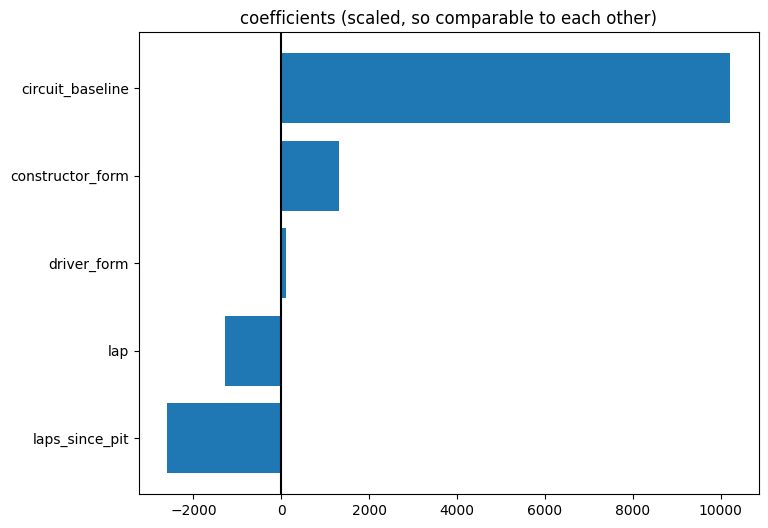

In [15]:
plt.figure(figsize=(8,6))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.axvline(0, color='black')
plt.title("coefficients (scaled, so comparable to each other)")
plt.show()


## check the errors

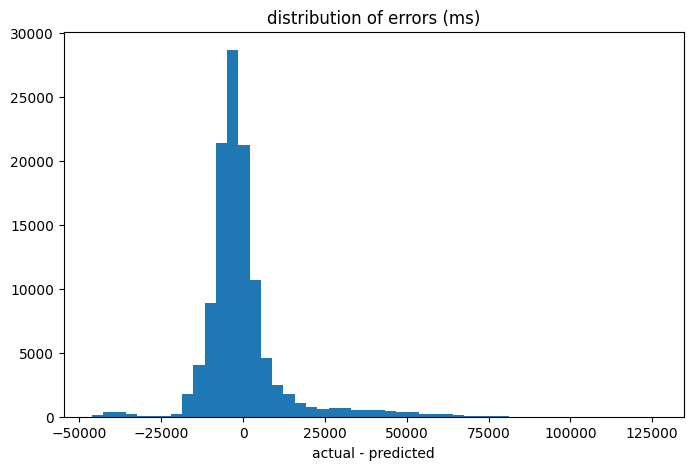

In [16]:
errors = y_test - preds

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("distribution of errors (ms)")
plt.xlabel("actual - predicted")
plt.show()


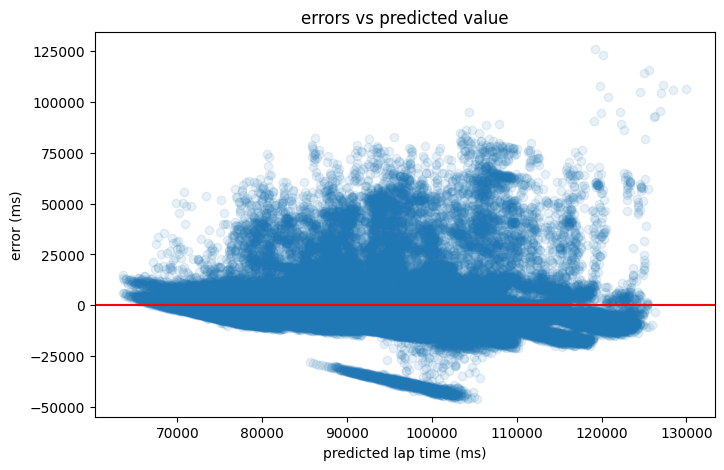

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(preds, errors, alpha=0.1)
plt.axhline(0, color='red')
plt.xlabel("predicted lap time (ms)")
plt.ylabel("error (ms)")
plt.title("errors vs predicted value")
plt.show()


## summary

- compare baseline MAE vs model MAE above - since milliseconds is a big
  number, might be easier to think in seconds (divide by 1000)
- unlike the position project, this target is a genuinely continuous
  number, so linear regression is a much more natural fit here
- the big limitation is still what's missing from the data - no tyre
  compound, no weather. laps_since_pit is a rough stand-in for tyre wear
  but it's not the same as knowing if someone's on soft or hard tyres,
  and a wet-weather lap will just look like a weird outlier to this model
  since there's no way to flag it
